<a href="https://colab.research.google.com/github/ajinfajrian/DataScience_240401020100_Fajrian/blob/master/Pertemuan9_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Fajrian Ichlasul Maruto \
**NIM:** 240401020100 \
**Kelas:** IF401 \
**Mata Kuliah:** Data Science \
**Pertemuan 9:** Algoritma Klasifikasi

### Import Library & Load Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk klasifikasi dan evaluasi
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load dataset kanker payudara
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target # 0: Malignant (Ganas), 1: Benign (Jinak)

print("Dimensi dataset:", df.shape)
df.head()

Dimensi dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Data Preprocessing (Split & Scaling)

In [6]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling data (Penting untuk Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 455
Jumlah data uji: 114


### Model 1 - Logistic Regression & Evaluasi

=== Evaluasi Logistic Regression ===
Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1-Score : 0.9790



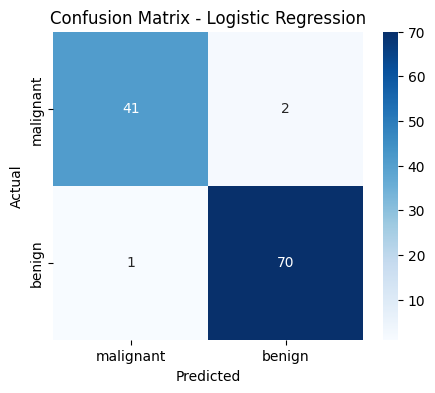

In [7]:
# 1. Inisialisasi dan Latih Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Prediksi
y_pred_log = log_reg.predict(X_test_scaled)

# 3. Evaluasi Metrik
print("=== Evaluasi Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_log):.4f}\n")

# 4. Visualisasi Confusion Matrix Heatmap
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=cancer_data.target_names, yticklabels=cancer_data.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 2 - Decision Tree & Evaluasi

=== Evaluasi Decision Tree ===
Accuracy : 0.9474
Precision: 0.9577
Recall   : 0.9577
F1-Score : 0.9577



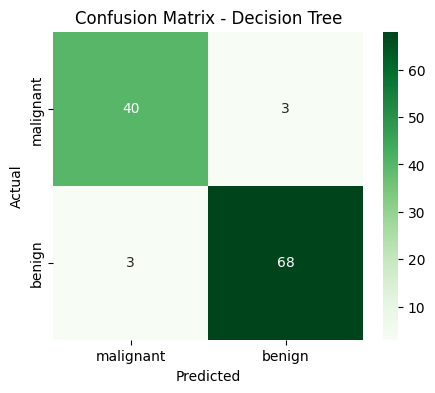

In [8]:
# 1. Inisialisasi dan Latih Model
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_clf.fit(X_train, y_train) # Decision Tree tidak wajib pakai data terskala

# 2. Prediksi
y_pred_tree = tree_clf.predict(X_test)

# 3. Evaluasi Metrik
print("=== Evaluasi Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_tree):.4f}\n")

# 4. Visualisasi Confusion Matrix Heatmap
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', xticklabels=cancer_data.target_names, yticklabels=cancer_data.target_names)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Jawaban Analisis Diagnosis

#### Analisis Hasil Prediksi Diagnosis (Logistic Regression vs Decision Tree)
1. **Perbandingan Metrik:** Berdasarkan hasil di atas, Logistic Regression menghasilkan performa yang sedikit lebih stabil dan metrik evaluasi yang lebih tinggi pada dataset ini dibandingkan Decision Tree dasar.
2. **Mengapa *Recall* paling kritis untuk kasus diagnosis kanker?**
Dalam diagnosis medis (terutama deteksi kanker), kita harus meminimalkan *False Negative* (pasien sebenarnya menderita kanker ganas, tetapi model memprediksinya sebagai tumor jinak). Kesalahan *Accuracy* atau *Precision* (memprediksi ganas padahal jinak) hanya akan berujung pada tes lanjutan, tetapi *Recall* yang rendah (melewatkan kanker yang sesungguhnya) bisa berakibat fatal pada nyawa pasien karena terlambat ditangani. Oleh karena itu, metrik *Recall* adalah fokus utama dalam skenario ini.

### Kesimpulan Pertemuan 9
* **Apa yang dipelajari:** Memahami cara kerja, melatih, dan membandingkan algoritma Logistic Regression dan Decision Tree untuk klasifikasi biner, serta mengevaluasi hasilnya menggunakan *Confusion Matrix*, *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.
* **Temuan utama:** Logistic Regression yang di-skala dengan baik (menggunakan `StandardScaler`) mampu mengungguli Decision Tree sederhana dalam mendeteksi kanker payudara dengan akurasi dan metrik pengujian yang sangat tinggi.
* **Keterbatasan/Pertanyaan:** Bagaimana cara menangani *overfitting* yang sering terjadi pada algoritma Decision Tree jika jumlah data (kedalaman pohon) semakin kompleks?